In [1]:

import pandas as pd
import json

# Load dataset
data = []
with open('../data/raw/dataset_raw.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except:
            pass

df = pd.DataFrame(data)

# Calculate length of content
df['content_length'] = df['content'].apply(lambda x: len(str(x)))

# Get top 20 shortest
shortest_20 = df.nsmallest(20, 'content_length')[['url', 'content_length', 'content']]
shortest_20


,url,content_length,content
5162,https://rumahpusbin.kemendikdasmen.go.id/berit...,28,https://youtu.be/F1BclAqM6iQ
5485,https://rumahpusbin.kemendikdasmen.go.id/berit...,39,elgerakanliterasinasional2023@gmail.com
2155,https://kemdiktisaintek.go.id/news/article/gma...,42,negara maju lainnya dalam kompetisi dunia.
686,https://badanbahasa.kemendikdasmen.go.id/page/...,43,sub/atauhttps://kemendikdasmen.lapor.go.id/
6507,https://www.kemendikdasmen.go.id/pengumuman/11...,44,Kemendikdasmen\n\nPengelola Web Kemendikdasmen
6523,https://www.kemendikdasmen.go.id/pengumuman/10...,44,Kemendikdasmen\n\nPengelola Web Kemendikdasmen
6537,https://www.kemendikdasmen.go.id/pengumuman/10...,44,Kemendikdasmen\n\nPengelola Web Kemendikdasmen
6541,https://www.kemendikdasmen.go.id/pengumuman/10...,44,Kemendikdasmen\n\nPengelola Web Kemendikdasmen
6543,https://www.kemendikdasmen.go.id/pengumuman/10...,44,Kemendikdasmen\n\nPengelola Web Kemendikdasmen
6545,https://www.kemendikdasmen.go.id/pengumuman/10...,44,Kemendikdasmen\n\nPengelola Web Kemendikdasmen


### URL Status Proportions

Status Proportions Table:


,status,count,proportion (%)
0,completed,14524,90.15
1,failed_too_short,1158,7.19
2,err_,312,1.94
3,err_Response payload is,93,0.58
4,err_Cannot connect to ho,18,0.11
5,err_database is locked,3,0.02
6,err_400,2,0.01
7,failed_not_html,1,0.01


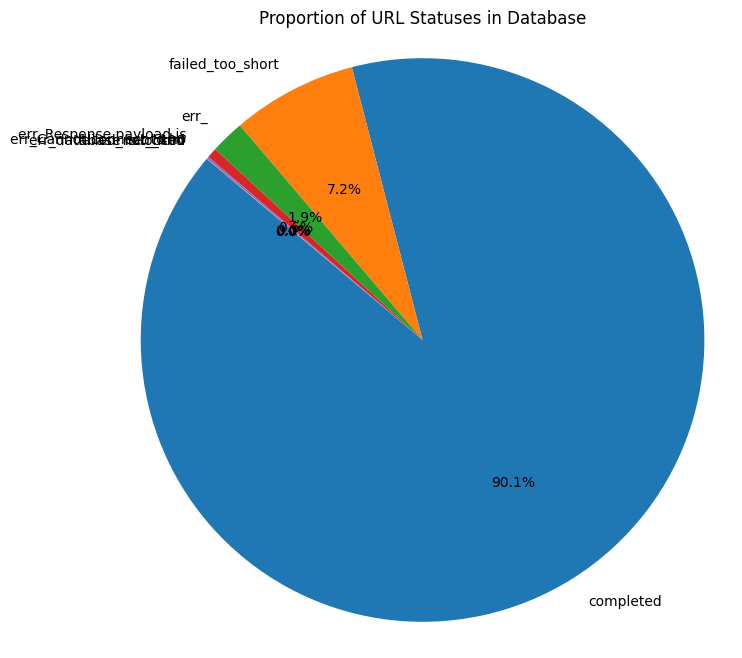

In [2]:

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect('../data/dedupe.sqlite3')

# Query the status proportions
query = '''
    SELECT status, COUNT(*) as count 
    FROM url_jobs 
    GROUP BY status
'''
df_status = pd.read_sql_query(query, conn)
conn.close()

# Calculate proportions
df_status['proportion (%)'] = (df_status['count'] / df_status['count'].sum() * 100).round(2)
df_status = df_status.sort_values(by='count', ascending=False).reset_index(drop=True)

# Display table
print("Status Proportions Table:")
display(df_status)

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(df_status['count'], labels=df_status['status'], autopct='%1.1f%%', startangle=140)
plt.title('Proportion of URL Statuses in Database')
plt.axis('equal')
plt.show()


In [3]:
import os
print(os.listdir('.')) 


['eda.ipynb']


In [4]:
import sqlite3

# Membuka koneksi ke database
conn = sqlite3.connect('../data/dedupe.sqlite3')
cur = conn.cursor()

# Menjalankan query
query = 'SELECT domain, COUNT(*) FROM url_jobs GROUP BY domain'
cur.execute(query)

# Mengambil dan menampilkan hasil
results = cur.fetchall()
for row in results:
    print(row)

# Menutup koneksi
conn.close()


('bskap.kemendikdasmen.go.id', 30)
('indonesia.travel', 50)
('indonesiakaya.com', 1621)
('kemdiktisaintek.go.id', 4989)
('kemenag.go.id', 14)
('kemendikdasmen.go.id', 5132)
('kemensos.go.id', 3097)
('lpdp.kemenkeu.go.id', 27)
('pusatprestasinasional.kemendikdasmen.go.id', 558)
('rumahpusbin.kemendikdasmen.go.id', 180)
('wonderfulindonesia.co.id', 413)


### Full EDA: Domain Coverage & Content Analysis

Status Breakdown by Domain:


status,completed,err_,err_400,err_Cannot connect to ho,err_Response payload is,err_database is locked,failed_not_html,failed_too_short
domain,,,,,,,,
kemendikdasmen.go.id,4851.0,216.0,2.0,13.0,0.0,2.0,0.0,48.0
kemdiktisaintek.go.id,4933.0,0.0,0.0,3.0,0.0,0.0,1.0,52.0
kemensos.go.id,2167.0,96.0,0.0,1.0,93.0,1.0,0.0,739.0
indonesiakaya.com,1445.0,0.0,0.0,1.0,0.0,0.0,0.0,175.0
pusatprestasinasional.kemendikdasmen.go.id,547.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0
wonderfulindonesia.co.id,397.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0
rumahpusbin.kemendikdasmen.go.id,129.0,0.0,0.0,0.0,0.0,0.0,0.0,51.0
indonesia.travel,1.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
bskap.kemendikdasmen.go.id,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


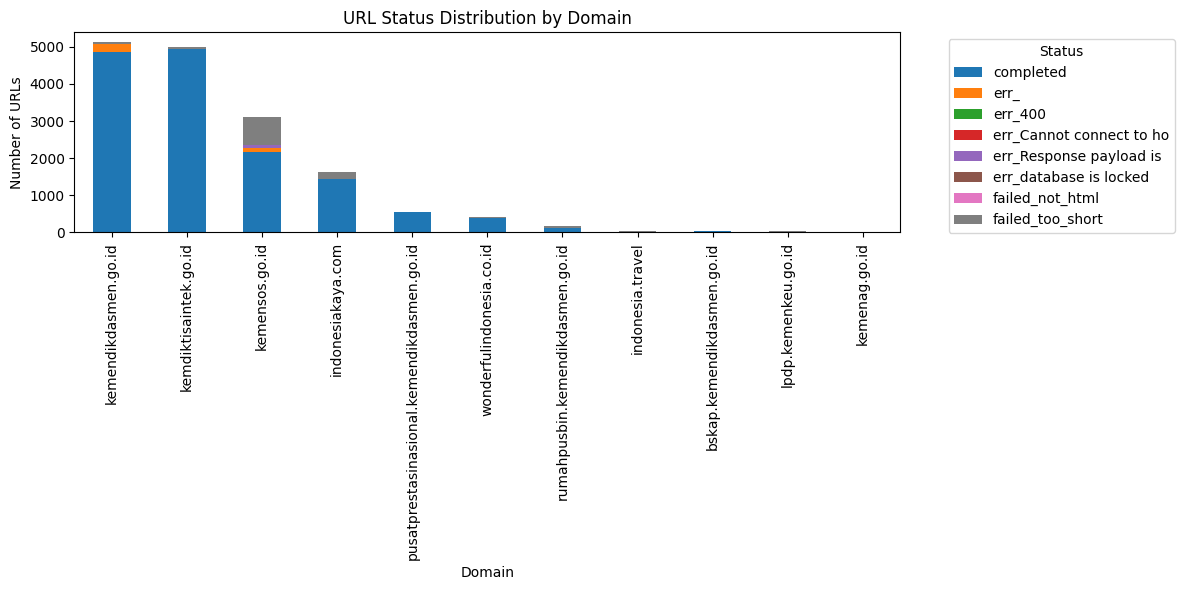

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect('../data/dedupe.sqlite3')

# Query the status proportions by domain
query = '''
    SELECT domain, status, COUNT(*) as count 
    FROM url_jobs 
    GROUP BY domain, status
    ORDER BY domain, count DESC
'''
df_domain_status = pd.read_sql_query(query, conn)
conn.close()

# Pivot for better visualization
pivot_df = df_domain_status.pivot(index='domain', columns='status', values='count').fillna(0)
pivot_df['total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values('total', ascending=False)
pivot_df = pivot_df.drop('total', axis=1)

print("Status Breakdown by Domain:")
display(pivot_df)

# Plotting
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('URL Status Distribution by Domain')
plt.xlabel('Domain')
plt.ylabel('Number of URLs')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Content Length Statistics by Domain:


,count,mean,min,max,median
domain,,,,,
kemdiktisaintek.go.id,5352,3399.60,42,19369,3219.5
www.kemendikdasmen.go.id,4809,4459.88,44,18284,4376.0
kemensos.go.id,2195,5294.80,60,20813,4874.0
indonesiakaya.com,1445,3404.57,125,22160,2725.0
pusatprestasinasional.kemendikdasmen.go.id,547,4882.21,104,32477,4619.0
wonderfulindonesia.co.id,397,8509.34,266,25323,6957.0
rumahpusbin.kemendikdasmen.go.id,163,2941.75,28,10239,3356.0
badanbahasa.kemendikdasmen.go.id,104,2390.62,43,19473,979.0
bskap.kemendikdasmen.go.id,94,3874.36,47,7007,3878.5


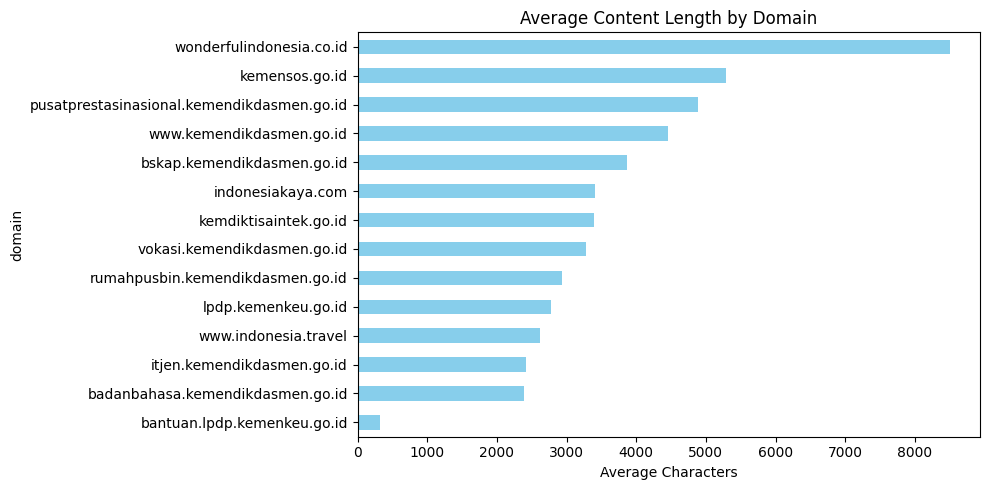

In [6]:
# Load dataset and analyze new domains
data = []
with open('../data/raw/dataset_raw.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except:
            pass

df = pd.DataFrame(data)
df['content_length'] = df['content'].apply(lambda x: len(str(x)))

# Extract domain from URL
from urllib.parse import urlparse
df['domain'] = df['url'].apply(lambda x: urlparse(x).netloc)

# Calculate mean, min, max content length by domain
domain_stats = df.groupby('domain')['content_length'].agg(['count', 'mean', 'min', 'max', 'median']).round(2)
domain_stats = domain_stats.sort_values('count', ascending=False)

print("Content Length Statistics by Domain:")
display(domain_stats)

# Plot average content length
plt.figure(figsize=(10, 5))
domain_stats['mean'].sort_values().plot(kind='barh', color='skyblue')
plt.title('Average Content Length by Domain')
plt.xlabel('Average Characters')
plt.tight_layout()
plt.show()


### Exhaustion Analysis

In [7]:
# Identify Exhausted Domains
# A domain is exhausted if it has no 'pending' URLs and its total URL count is stagnant.
conn = sqlite3.connect('../data/dedupe.sqlite3')
query = '''
    SELECT domain, 
           SUM(CASE WHEN status = 'pending' THEN 1 ELSE 0 END) as pending_count,
           SUM(CASE WHEN status = 'completed' THEN 1 ELSE 0 END) as completed_count,
           COUNT(*) as total_urls
    FROM url_jobs 
    GROUP BY domain
    ORDER BY total_urls DESC
'''
df_exhaustion = pd.read_sql_query(query, conn)
conn.close()

df_exhaustion['is_exhausted'] = df_exhaustion['pending_count'] == 0

print("Domain Exhaustion Status:")
display(df_exhaustion)


Domain Exhaustion Status:


,domain,pending_count,completed_count,total_urls,is_exhausted
0,kemendikdasmen.go.id,0,4851,5132,True
1,kemdiktisaintek.go.id,0,4933,4989,True
2,kemensos.go.id,0,2167,3097,True
3,indonesiakaya.com,0,1445,1621,True
4,pusatprestasinasional.kemendikdasmen.go.id,0,547,558,True
5,wonderfulindonesia.co.id,0,397,413,True
6,rumahpusbin.kemendikdasmen.go.id,0,129,180,True
7,indonesia.travel,0,1,50,True
8,bskap.kemendikdasmen.go.id,0,30,30,True
9,lpdp.kemenkeu.go.id,0,24,27,True


### Full EDA: Domain Coverage & Content Analysis

Status Breakdown by Domain:


status,completed,err_,err_400,err_Cannot connect to ho,err_Response payload is,err_database is locked,failed_not_html,failed_too_short
domain,,,,,,,,
kemendikdasmen.go.id,4851.0,216.0,2.0,13.0,0.0,2.0,0.0,48.0
kemdiktisaintek.go.id,4933.0,0.0,0.0,3.0,0.0,0.0,1.0,52.0
kemensos.go.id,2167.0,96.0,0.0,1.0,93.0,1.0,0.0,739.0
indonesiakaya.com,1445.0,0.0,0.0,1.0,0.0,0.0,0.0,175.0
pusatprestasinasional.kemendikdasmen.go.id,547.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0
wonderfulindonesia.co.id,397.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0
rumahpusbin.kemendikdasmen.go.id,129.0,0.0,0.0,0.0,0.0,0.0,0.0,51.0
indonesia.travel,1.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
bskap.kemendikdasmen.go.id,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


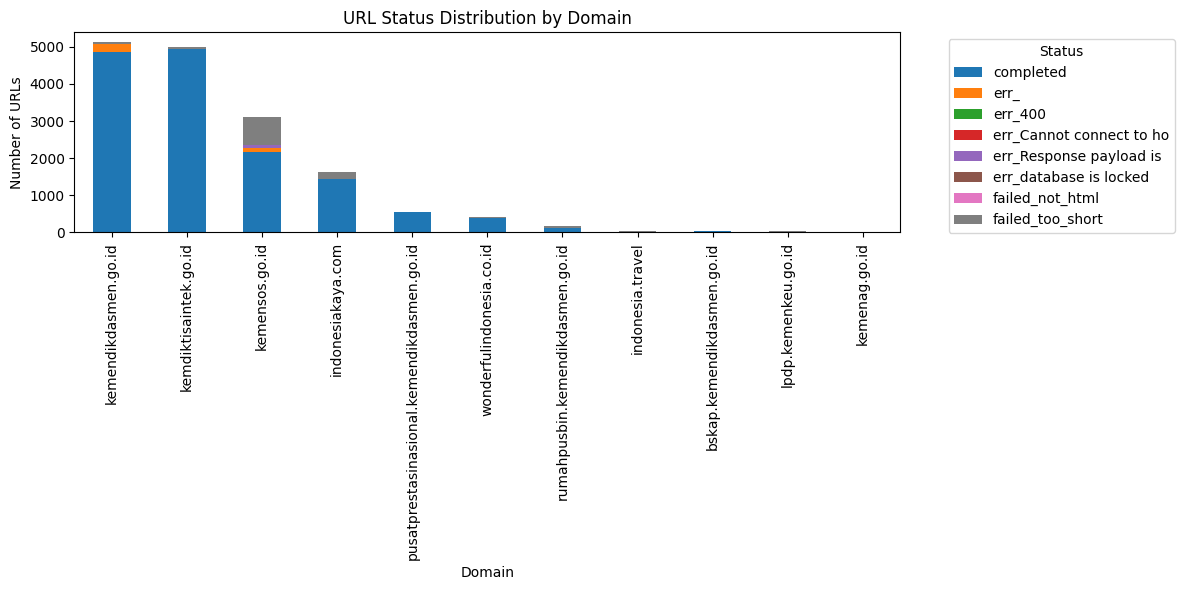

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect('../data/dedupe.sqlite3')

# Query the status proportions by domain
query = '''
    SELECT domain, status, COUNT(*) as count 
    FROM url_jobs 
    GROUP BY domain, status
    ORDER BY domain, count DESC
'''
df_domain_status = pd.read_sql_query(query, conn)
conn.close()

# Pivot for better visualization
pivot_df = df_domain_status.pivot(index='domain', columns='status', values='count').fillna(0)
pivot_df['total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values('total', ascending=False)
pivot_df = pivot_df.drop('total', axis=1)

print("Status Breakdown by Domain:")
display(pivot_df)

# Plotting
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('URL Status Distribution by Domain')
plt.xlabel('Domain')
plt.ylabel('Number of URLs')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Content Length Statistics by Domain:


,count,mean,min,max,median
domain,,,,,
kemdiktisaintek.go.id,5352,3399.60,42,19369,3219.5
www.kemendikdasmen.go.id,4809,4459.88,44,18284,4376.0
kemensos.go.id,2195,5294.80,60,20813,4874.0
indonesiakaya.com,1445,3404.57,125,22160,2725.0
pusatprestasinasional.kemendikdasmen.go.id,547,4882.21,104,32477,4619.0
wonderfulindonesia.co.id,397,8509.34,266,25323,6957.0
rumahpusbin.kemendikdasmen.go.id,163,2941.75,28,10239,3356.0
badanbahasa.kemendikdasmen.go.id,104,2390.62,43,19473,979.0
bskap.kemendikdasmen.go.id,94,3874.36,47,7007,3878.5


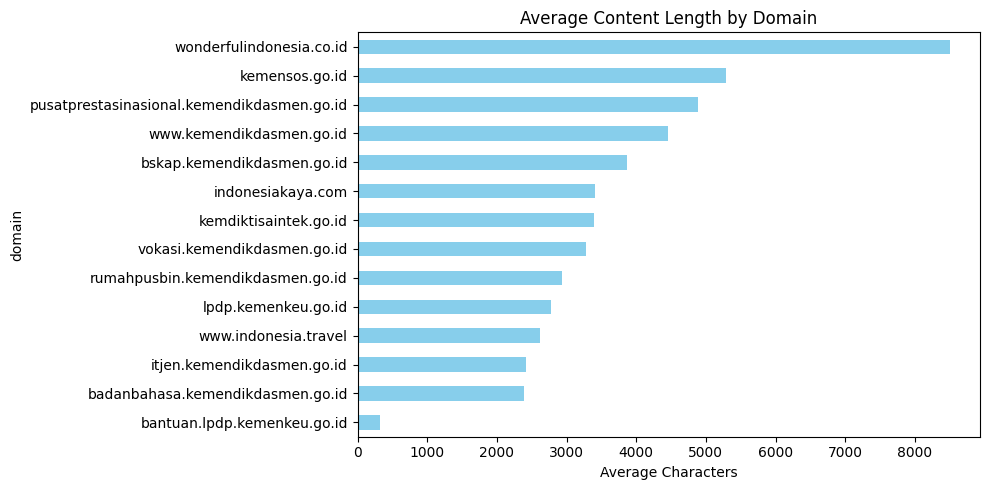

In [9]:
# Load dataset and analyze new domains
data = []
with open('../data/raw/dataset_raw.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except:
            pass

df = pd.DataFrame(data)
df['content_length'] = df['content'].apply(lambda x: len(str(x)))

# Extract domain from URL
from urllib.parse import urlparse
df['domain'] = df['url'].apply(lambda x: urlparse(x).netloc)

# Calculate mean, min, max content length by domain
domain_stats = df.groupby('domain')['content_length'].agg(['count', 'mean', 'min', 'max', 'median']).round(2)
domain_stats = domain_stats.sort_values('count', ascending=False)

print("Content Length Statistics by Domain:")
display(domain_stats)

# Plot average content length
plt.figure(figsize=(10, 5))
domain_stats['mean'].sort_values().plot(kind='barh', color='skyblue')
plt.title('Average Content Length by Domain')
plt.xlabel('Average Characters')
plt.tight_layout()
plt.show()


### Exhaustion Analysis

In [10]:
# Identify Exhausted Domains
# A domain is exhausted if it has no 'pending' URLs and its total URL count is stagnant.
conn = sqlite3.connect('../data/dedupe.sqlite3')
query = '''
    SELECT domain, 
           SUM(CASE WHEN status = 'pending' THEN 1 ELSE 0 END) as pending_count,
           SUM(CASE WHEN status = 'completed' THEN 1 ELSE 0 END) as completed_count,
           COUNT(*) as total_urls
    FROM url_jobs 
    GROUP BY domain
    ORDER BY total_urls DESC
'''
df_exhaustion = pd.read_sql_query(query, conn)
conn.close()

df_exhaustion['is_exhausted'] = df_exhaustion['pending_count'] == 0

print("Domain Exhaustion Status:")
display(df_exhaustion)


Domain Exhaustion Status:


,domain,pending_count,completed_count,total_urls,is_exhausted
0,kemendikdasmen.go.id,0,4851,5132,True
1,kemdiktisaintek.go.id,0,4933,4989,True
2,kemensos.go.id,0,2167,3097,True
3,indonesiakaya.com,0,1445,1621,True
4,pusatprestasinasional.kemendikdasmen.go.id,0,547,558,True
5,wonderfulindonesia.co.id,0,397,413,True
6,rumahpusbin.kemendikdasmen.go.id,0,129,180,True
7,indonesia.travel,0,1,50,True
8,bskap.kemendikdasmen.go.id,0,30,30,True
9,lpdp.kemenkeu.go.id,0,24,27,True
